# Experiment: Rho-and-fsurf-first binned multi-model-mean Fgen comparison

Compare rho-and-fsurf-first Fgen from binned multi-model fields with the equal-model mean of the existing native-grid results from `Fgenrun2_streaming.py`.

Success criteria:

- Use the exact 16-model cohort recorded by the MMM calculation, excluding `SAM0-UNICON`.
- Require density and surface-forcing components to be calculated per model before the equal-model mean.
- Require exact density-coordinate equality before any profile comparison.
- Inspect model coverage and the effective common-grid area.
- Compare Fgen, heat, and freshwater profiles and quantify their Fgen difference.


## Inputs and experiment plan

Run `scripts/FgenCalculation/Fgen_mean_calculation.py` first. This notebook reads its MMM pickle and eight NetCDF products (`tos`, `sos`, `hfds`, `wfo`, `rho`, `fsurf`, `heat_comp`, and `fw_comp`); it reads the existing `Fgen_Allmodels_streaming.pkl` directly and does not regenerate the native-grid baseline.

The primary comparison is rho-and-fsurf-first Fgen versus the equal-weight mean of the same 16 models' legacy Fgen profiles. For each model, rho, alpha, beta, heat forcing, freshwater forcing, and fsurf are calculated from its regridded 20-year monthly climatologies; those derived fields are then averaged with the shared contributor mask. This is neither a diagnostic of the averaged raw inputs nor a mean of diagnostics from 240 individual months. Saved MMM rho controls density-bin assignment, and saved MMM fsurf/heat/freshwater fields control integration. `SAM0-UNICON`, both FGOALS models, and CESM2 are excluded. Plots and profile metrics use densities at or above `RHO_PLOT_MIN`.


In [1]:
from __future__ import annotations

from collections.abc import Mapping
from pathlib import Path
import pickle

import gsw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

MMM_DIR = Path("/glade/work/stevenxu/AMOC_models/MMM_binned_1deg_no_SAM0_rho_fsurf_first")
MMM_RESULT_PATH = MMM_DIR / "MMM_Fgen_binned_1deg.pkl"
LEGACY_RESULT_PATH = Path("/glade/work/stevenxu/AMOC_models/Fgen_Allmodels_streaming.pkl")

RHO_PLOT_MIN = 1020.0
EXPECTED_MODELS = (
    "ACCESS-CM2", "ACCESS-ESM1-5", "CAS-ESM2-0", "CanESM5",
    "CanESM5-1", "E3SM-1-0", "GISS-E2-1-G-CC", "GISS-E2-2-G",
    "ICON-ESM-LR", "MIROC6", "MPI-ESM-1-2-HAM", "MPI-ESM1-2-HR",
    "MPI-ESM1-2-LR", "MRI-ESM2-0", "NorESM2-LM", "NorESM2-MM",
)
EXPECTED_MODEL_COUNT = len(EXPECTED_MODELS)
EXCLUDED_MODELS = {"CESM2", "FGOALS-f3-L", "FGOALS-g3", "SAM0-UNICON"}
PROFILE_COLUMNS = ["Fgen", "HeatFlux", "FreshwaterFlux", "AreaSum"]
OUTPUT_VARIABLES = ("tos", "sos", "hfds", "wfo", "rho", "fsurf", "heat_comp", "fw_comp")


## Load results

Fail early with an actionable message if the full MMM calculation has not produced its final result yet.


In [2]:
if not MMM_RESULT_PATH.exists():
    raise FileNotFoundError(
        f"Missing {MMM_RESULT_PATH}. Run Fgen_mean_calculation.py to completion first."
    )
if not LEGACY_RESULT_PATH.exists():
    raise FileNotFoundError(f"Missing legacy baseline: {LEGACY_RESULT_PATH}")

with MMM_RESULT_PATH.open("rb") as handle:
    mmm_payload = pickle.load(handle)
with LEGACY_RESULT_PATH.open("rb") as handle:
    legacy_results = pickle.load(handle)

if not isinstance(mmm_payload, Mapping):
    raise TypeError("MMM result must be a mapping with 'metadata' and 'result' entries")
if not isinstance(legacy_results, Mapping):
    raise TypeError("Legacy result must be a model-to-DataFrame mapping")

metadata = dict(mmm_payload["metadata"])
mmm_result = mmm_payload["result"]
if not isinstance(mmm_result, pd.DataFrame):
    raise TypeError("MMM payload['result'] must be a pandas DataFrame")

print("MMM result:", MMM_RESULT_PATH)
print("Legacy baseline:", LEGACY_RESULT_PATH)


MMM result: /glade/work/stevenxu/AMOC_models/MMM_binned_1deg_no_SAM0_rho_fsurf_first/MMM_Fgen_binned_1deg.pkl
Legacy baseline: /glade/work/stevenxu/AMOC_models/Fgen_Allmodels_streaming.pkl


## Cohort and density-coordinate validation

The metadata-defined cohort is authoritative. Every selected legacy profile must contain the required columns and exactly the same ordered `rho` values as the MMM profile.


In [3]:
REQUIRED_METADATA = {
    "models_processed",
    "output_files",
    "resolution_degrees",
    "source_months",
    "temporal_aggregation",
    "step_size",
    "area_method",
    "density_aggregation",
    "forcing_coefficient_aggregation",
    "surface_forcing_method",
    "surface_forcing_constants",
    "surface_forcing_aggregation",
    "surface_forcing_source",
    "density_binning_source",
    "model_count_min",
    "model_count_max",
    "rho_source_file",
    "surface_forcing_source_files",
    "operation_order_qc",
    "rho_qc",
    "surface_forcing_qc",
}
missing_metadata = sorted(REQUIRED_METADATA - set(metadata))
if missing_metadata:
    raise KeyError(f"MMM metadata is missing required entries: {missing_metadata}")

models_processed = list(metadata["models_processed"])
if len(models_processed) != len(set(models_processed)):
    raise AssertionError("metadata['models_processed'] contains duplicate models")
if len(models_processed) != EXPECTED_MODEL_COUNT:
    raise AssertionError(
        f"Expected {EXPECTED_MODEL_COUNT} completed models, found {len(models_processed)}"
    )
unexpected_excluded = sorted(set(models_processed) & EXCLUDED_MODELS)
if unexpected_excluded:
    raise AssertionError(f"Excluded models found in MMM cohort: {unexpected_excluded}")
if tuple(models_processed) != EXPECTED_MODELS:
    raise AssertionError(
        "MMM cohort or ordering differs from the exact expected 16-model cohort"
    )

missing_legacy = [model for model in models_processed if model not in legacy_results]
if missing_legacy:
    raise KeyError(f"Models missing from the legacy baseline: {missing_legacy}")

def validate_profile(profile: pd.DataFrame, label: str) -> pd.DataFrame:
    if not isinstance(profile, pd.DataFrame):
        raise TypeError(f"{label} is not a pandas DataFrame")
    required_columns = {"rho", *PROFILE_COLUMNS}
    missing_columns = sorted(required_columns - set(profile.columns))
    if missing_columns:
        raise KeyError(f"{label} is missing columns: {missing_columns}")
    ordered = profile[["rho", *PROFILE_COLUMNS]].sort_values("rho").reset_index(drop=True)
    if ordered["rho"].duplicated().any():
        raise AssertionError(f"{label} has duplicate density coordinates")
    if not ordered["rho"].is_monotonic_increasing:
        raise AssertionError(f"{label} density coordinates are not increasing")
    return ordered

mmm_profile = validate_profile(mmm_result, "MMM result")
mmm_rho = mmm_profile["rho"].to_numpy()
legacy_profiles = {
    model: validate_profile(legacy_results[model], f"legacy {model}")
    for model in models_processed
}
for model, profile in legacy_profiles.items():
    if not np.array_equal(profile["rho"].to_numpy(), mmm_rho):
        raise AssertionError(f"Density coordinates differ exactly for {model} and MMM")

step_size = float(metadata["step_size"])
if not np.allclose(np.diff(mmm_rho), step_size, rtol=0.0, atol=1e-10):
    raise AssertionError("MMM density spacing does not match metadata['step_size']")

cohort = pd.DataFrame(
    {
        "model": models_processed,
        "in_MMM": True,
        "legacy_profile_available": [model in legacy_results for model in models_processed],
        "rho_coordinates_exact": True,
    }
)
print(f"Validated {len(models_processed)} models and {len(mmm_rho)} exact density bins.")
display(cohort)


Validated 16 models and 302 exact density bins.


,model,in_MMM,legacy_profile_available,rho_coordinates_exact
0,ACCESS-CM2,True,True,True
1,ACCESS-ESM1-5,True,True,True
2,CAS-ESM2-0,True,True,True
3,CanESM5,True,True,True
4,CanESM5-1,True,True,True
5,E3SM-1-0,True,True,True
6,GISS-E2-1-G-CC,True,True,True
7,GISS-E2-2-G,True,True,True
8,ICON-ESM-LR,True,True,True
9,MIROC6,True,True,True


In [4]:
metadata_fields = [
    "resolution_degrees",
    "source_months",
    "temporal_aggregation",
    "step_size",
    "area_method",
    "density_aggregation",
    "forcing_coefficient_aggregation",
    "surface_forcing_aggregation",
    "surface_forcing_source",
    "density_binning_source",
    "model_count_min",
    "model_count_max",
]
metadata_summary = pd.Series(
    {field: metadata[field] for field in metadata_fields},
    name="value",
).to_frame()
metadata_summary.loc["models_processed"] = len(models_processed)
display(metadata_summary)


,value
resolution_degrees,1.0
source_months,240
temporal_aggregation,per-model calendar-month climatology
step_size,0.05
area_method,mean source area assigned from each model's na...
density_aggregation,per-model density from regridded monthly-clima...
forcing_coefficient_aggregation,alpha and beta calculated separately for each ...
surface_forcing_aggregation,per-model heat and freshwater forcing componen...
surface_forcing_source,"saved per-model-first MMM fsurf, heat_comp, an..."
density_binning_source,saved rho-first MMM field


## Common-grid coverage and area diagnostics

Open the eight final MMM products, verify their 12-month 1-degree shape, and require identical `model_count` and `areacello` fields. Every raw and derived field must be finite exactly where the shared contributor count is positive. Coverage statistics exclude zero-contributor land/unassigned cells when reporting positive-cell minima.


In [5]:
def resolve_output_files(raw_output_files) -> dict[str, Path]:
    if isinstance(raw_output_files, Mapping):
        entries = list(raw_output_files.items())
    elif isinstance(raw_output_files, (list, tuple)):
        entries = [("", value) for value in raw_output_files]
    else:
        raise TypeError("metadata['output_files'] must be a mapping or sequence")

    resolved = {}
    for label, raw_path in entries:
        path = Path(raw_path)
        if not path.is_absolute():
            path = MMM_DIR / path
        variable = str(label) if str(label) in OUTPUT_VARIABLES else None
        if variable is None:
            padded_stem = f"_{path.stem}_"
            variable = next((name for name in sorted(OUTPUT_VARIABLES, key=len, reverse=True) if f"_{name}_" in padded_stem), None)
        if variable is None:
            continue
        if variable in resolved:
            raise ValueError(f"Duplicate output file for {variable}")
        resolved[variable] = path

    if set(resolved) != set(OUTPUT_VARIABLES):
        raise KeyError(
            f"Expected output files for {list(OUTPUT_VARIABLES)}, found {sorted(resolved)}"
        )
    return resolved

output_files = resolve_output_files(metadata["output_files"])
if Path(metadata["rho_source_file"]) != output_files["rho"]:
    raise AssertionError("rho_source_file does not point to the saved rho product")
for variable in ("fsurf", "heat_comp", "fw_comp"):
    if Path(metadata["surface_forcing_source_files"][variable]) != output_files[variable]:
        raise AssertionError(f"surface forcing source does not match saved {variable}")
missing_output_files = [str(path) for path in output_files.values() if not path.exists()]
if missing_output_files:
    raise FileNotFoundError(f"Missing final MMM NetCDF files: {missing_output_files}")

resolution = float(metadata["resolution_degrees"])
expected_sizes = {
    "time": 12,
    "lat": int(round(180.0 / resolution)),
    "lon": int(round(360.0 / resolution)),
}
file_rows = []
loaded_fields = {}
model_count_reference = None
area_reference = None

for variable in OUTPUT_VARIABLES:
    path = output_files[variable]
    with xr.open_dataset(path, engine="h5netcdf") as dataset:
        required_variables = {variable, "model_count", "areacello"}
        missing_variables = sorted(required_variables - set(dataset.variables))
        if missing_variables:
            raise KeyError(f"{path.name} is missing variables: {missing_variables}")
        expected_variable_dims = ("time", "lat", "lon")
        if dataset[variable].dims != expected_variable_dims:
            raise AssertionError(f"Unexpected {variable} dimensions in {path.name}: {dataset[variable].dims}")
        if dataset["model_count"].dims != expected_variable_dims:
            raise AssertionError(f"Unexpected model_count dimensions in {path.name}")
        if dataset["areacello"].dims != ("lat", "lon"):
            raise AssertionError(f"Unexpected areacello dimensions in {path.name}")
        actual_sizes = {name: dataset.sizes.get(name) for name in expected_sizes}
        if actual_sizes != expected_sizes:
            raise AssertionError(
                f"Unexpected dimensions in {path.name}: {actual_sizes}; expected {expected_sizes}"
            )
        try:
            calendar_months = np.asarray(dataset["time"].dt.month.values, dtype=int)
        except (AttributeError, TypeError):
            calendar_months = np.asarray(dataset["time"].values, dtype=int)
        if not np.array_equal(calendar_months, np.arange(1, 13)):
            raise AssertionError(f"{path.name} time coordinate is not ordered January through December")

        field = dataset[variable].load()
        model_count = dataset["model_count"].load()
        area = dataset["areacello"].load()
        if not np.array_equal(np.isfinite(field.values), model_count.values > 0):
            raise AssertionError(f"{variable} finite mask differs from model_count")
        if variable == "rho" and field.attrs.get("units") != "kg m-3":
            raise AssertionError("MMM rho units must be kg m-3")
        if variable == "rho" and field.attrs.get("density_aggregation") != metadata["density_aggregation"]:
            raise AssertionError("MMM rho operation-order metadata is inconsistent")
        if variable in {"fsurf", "heat_comp", "fw_comp"}:
            if field.attrs.get("units") != "kg m-2 s-1":
                raise AssertionError(f"MMM {variable} units must be kg m-2 s-1")
            if field.attrs.get("forcing_method") != metadata["surface_forcing_method"]:
                raise AssertionError(f"MMM {variable} forcing method is inconsistent")
            if field.attrs.get("surface_forcing_aggregation") != metadata["surface_forcing_aggregation"]:
                raise AssertionError(f"MMM {variable} operation-order metadata is inconsistent")
        loaded_fields[variable] = field
        if model_count_reference is None:
            model_count_reference = model_count.copy(deep=True)
            area_reference = area.copy(deep=True)
        else:
            xr.testing.assert_equal(model_count, model_count_reference)
            xr.testing.assert_equal(area, area_reference)

        count_values = np.asarray(model_count.values, dtype=float)
        positive_counts = count_values[np.isfinite(count_values) & (count_values > 0)]
        file_rows.append(
            {
                "variable": variable,
                "file": str(path),
                "shape": tuple(field.shape),
                "finite_data_fraction": float(field.notnull().mean().item()),
                "positive_count_min": int(positive_counts.min()),
                "count_max": int(positive_counts.max()),
                "effective_area_m2": float(area.where(area > 0).sum(skipna=True).item()),
            }
        )

file_diagnostics = pd.DataFrame(file_rows).set_index("variable")
forcing_closure = loaded_fields["fsurf"] - loaded_fields["heat_comp"] - loaded_fields["fw_comp"]
if not np.allclose(forcing_closure.values[np.isfinite(forcing_closure.values)], 0.0, rtol=1e-12, atol=1e-18):
    raise AssertionError("Saved MMM fsurf differs from heat_comp + fw_comp")
display(file_diagnostics)


,file,shape,finite_data_fraction,positive_count_min,count_max,effective_area_m2
variable,,,,,,
tos,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14
sos,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14
hfds,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14
wfo,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14
rho,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14
fsurf,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14
heat_comp,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14
fw_comp,/glade/work/stevenxu/AMOC_models/MMM_binned_1d...,"(12, 180, 360)",0.701451,1,16,3.797224e+14


## Density and surface-forcing operation-order diagnostics

Compare the saved means of each model's derived rho and forcing fields with the same diagnostics calculated from the averaged raw MMM inputs. The saved fields are used by Fgen; the diagnostics of averaged inputs are references only.


,units,finite_cells,mean_difference,rmse_difference,maximum_absolute_difference,minimum_difference,maximum_difference
variable,,,,,,,
rho,kg m-3,545448,-6.514196e-03,1.133106e-02,0.429530,-4.295297e-01,0.035388
fsurf,kg m-2 s-1,545448,-1.409117e-08,6.732725e-08,0.000005,-4.999381e-06,0.000003
heat_comp,kg m-2 s-1,545448,-1.454357e-08,6.968323e-08,0.000008,-8.338563e-06,0.000003
fw_comp,kg m-2 s-1,545448,4.523977e-10,1.871633e-08,0.000005,-6.254093e-07,0.000005


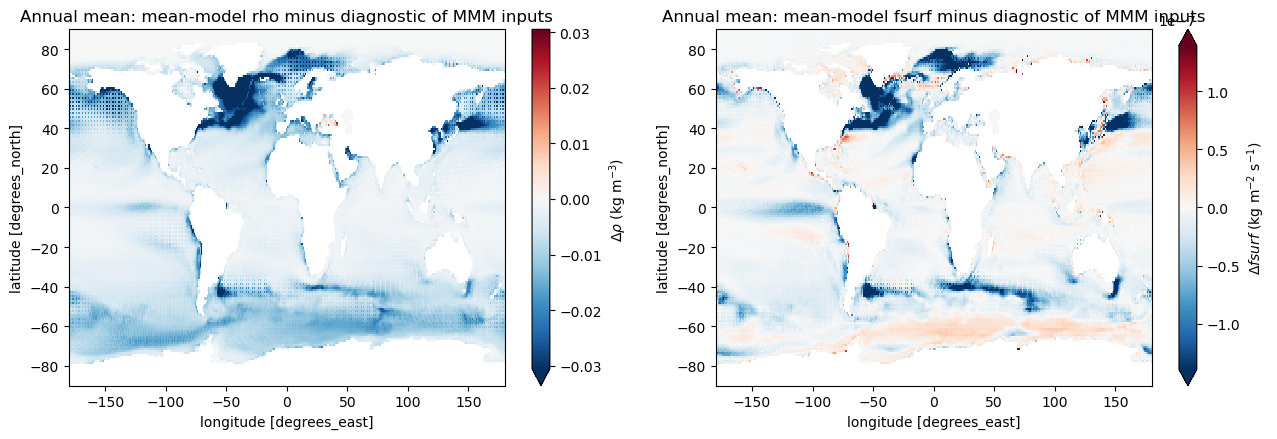

In [6]:
constants = metadata["surface_forcing_constants"]
cp = float(constants["cp_J_kg-1_K-1"])
rho0 = float(constants["rho0_kg_m-3"])
rho_fw = float(constants["rho_fw_kg_m-3"])
S0 = float(constants["S0"])

rho_from_averaged_inputs = xr.apply_ufunc(
    gsw.density.rho, loaded_fields["sos"], loaded_fields["tos"], 0.0, output_dtypes=[float]
).rename("rho")
alpha_from_averaged_inputs = xr.apply_ufunc(
    gsw.density.alpha, loaded_fields["sos"], loaded_fields["tos"], 0.0, output_dtypes=[float]
)
beta_from_averaged_inputs = xr.apply_ufunc(
    gsw.density.beta, loaded_fields["sos"], loaded_fields["tos"], 0.0, output_dtypes=[float]
)
heat_from_averaged_inputs = (
    (alpha_from_averaged_inputs / cp) * loaded_fields["hfds"]
).rename("heat_comp")
fw_from_averaged_inputs = (
    (rho0 / rho_fw) * beta_from_averaged_inputs * S0 * loaded_fields["wfo"]
).rename("fw_comp")
derived_from_averaged_inputs = {
    "rho": rho_from_averaged_inputs,
    "heat_comp": heat_from_averaged_inputs,
    "fw_comp": fw_from_averaged_inputs,
    "fsurf": (heat_from_averaged_inputs + fw_from_averaged_inputs).rename("fsurf"),
}

def operation_order_metrics(difference: xr.DataArray) -> dict[str, float]:
    finite = np.asarray(difference.values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        raise AssertionError(f"No finite operation-order differences for {difference.name}")
    return {
        "finite_cells": int(finite.size),
        "mean_difference": float(finite.mean()),
        "rmse_difference": float(np.sqrt(np.mean(finite**2))),
        "maximum_absolute_difference": float(np.max(np.abs(finite))),
        "minimum_difference": float(finite.min()),
        "maximum_difference": float(finite.max()),
    }

order_differences = {}
order_rows = []
if metadata["rho_qc"] != metadata["operation_order_qc"]["rho"]:
    raise AssertionError("rho_qc alias differs from operation_order_qc['rho']")
if metadata["surface_forcing_qc"] != {key: metadata["operation_order_qc"][key] for key in ("fsurf", "heat_comp", "fw_comp")}:
    raise AssertionError("surface_forcing_qc differs from operation_order_qc")
for variable in ("rho", "fsurf", "heat_comp", "fw_comp"):
    difference = (
        loaded_fields[variable] - derived_from_averaged_inputs[variable]
    ).rename(variable)
    order_differences[variable] = difference
    observed = operation_order_metrics(difference)
    expected = metadata["operation_order_qc"][variable]
    tolerance = 1e-12 if variable == "rho" else 1e-18
    if observed["finite_cells"] != int(expected["finite_cells"]):
        raise AssertionError(f"{variable} QC finite-cell mismatch")
    for metric in ("mean_difference", "rmse_difference", "maximum_absolute_difference", "minimum_difference", "maximum_difference"):
        if not np.isclose(observed[metric], float(expected[metric]), rtol=1e-12, atol=tolerance):
            raise AssertionError(f"{variable} QC mismatch for {metric}")
    order_rows.append({"variable": variable, "units": expected["units"], **observed})

operation_order_table = pd.DataFrame(order_rows).set_index("variable")
display(operation_order_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, variable, colorbar_label in zip(
    axes,
    ("rho", "fsurf"),
    (r"$\Delta\rho$ (kg m$^{-3}$)", r"$\Delta fsurf$ (kg m$^{-2}$ s$^{-1}$)"),
):
    order_differences[variable].mean("time", skipna=True).plot(
        ax=axis, cmap="RdBu_r", center=0.0, robust=True,
        cbar_kwargs={"label": colorbar_label},
    )
    axis.set_title(f"Annual mean: mean-model {variable} minus diagnostic of MMM inputs")
plt.tight_layout()
plt.show()


In [7]:
count_values = np.asarray(model_count_reference.values, dtype=float)
finite_counts = count_values[np.isfinite(count_values)]
positive_counts = finite_counts[finite_counts > 0]
if positive_counts.size == 0:
    raise AssertionError("The common grid has no positive model_count cells")

observed_count_min_all = int(finite_counts.min())
observed_count_min_positive = int(positive_counts.min())
observed_count_max = int(positive_counts.max())
metadata_count_min = int(metadata["model_count_min"])
metadata_count_max = int(metadata["model_count_max"])
if metadata_count_min not in {observed_count_min_all, observed_count_min_positive}:
    raise AssertionError("metadata model_count_min does not match all-cell or positive-cell coverage")
if metadata_count_max != observed_count_max:
    raise AssertionError("metadata model_count_max does not match NetCDF coverage")

coverage_rows = []
for month_index in range(model_count_reference.sizes["time"]):
    month_count = model_count_reference.isel(time=month_index)
    values = np.asarray(month_count.values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    month_label = str(model_count_reference["time"].values[month_index])
    coverage_rows.append(
        {
            "month": month_label,
            "covered_cells": values.size,
            "model_count_min": int(values.min()),
            "model_count_mean": float(values.mean()),
            "model_count_max": int(values.max()),
            "full_cohort_cells": int(np.count_nonzero(values == EXPECTED_MODEL_COUNT)),
        }
    )
coverage_by_month = pd.DataFrame(coverage_rows)

count_histogram = (
    pd.Series(positive_counts.astype(int), name="model_count")
    .value_counts()
    .sort_index()
    .rename("cell_months")
    .to_frame()
)

normalized_lon = ((area_reference["lon"] + 180.0) % 360.0) - 180.0
north_atlantic_mask = (
    (area_reference["lat"] > 45.0)
    & (normalized_lon >= -90.0)
    & (normalized_lon <= 60.0)
)
positive_area = area_reference.where(area_reference > 0)
area_diagnostics = pd.Series(
    {
        "area_method": metadata["area_method"],
        "effective_global_ocean_area_m2": float(positive_area.sum(skipna=True).item()),
        "effective_North_Atlantic_area_m2": float(positive_area.where(north_atlantic_mask).sum(skipna=True).item()),
        "positive_area_cells": int(positive_area.count().item()),
        "all_cell_model_count_min": observed_count_min_all,
        "positive_cell_model_count_min": observed_count_min_positive,
        "model_count_max": observed_count_max,
    },
    name="value",
).to_frame()
display(area_diagnostics)
display(coverage_by_month)
display(count_histogram)


,value
area_method,mean source area assigned from each model's na...
effective_global_ocean_area_m2,379722437433299.125
effective_North_Atlantic_area_m2,17986827757036.859375
positive_area_cells,49431
all_cell_model_count_min,0
positive_cell_model_count_min,1
model_count_max,16


,month,covered_cells,model_count_min,model_count_mean,model_count_max,full_cohort_cells
0,1,45454,1,12.523342,16,4522
1,2,45454,1,12.523342,16,4522
2,3,45454,1,12.523342,16,4522
3,4,45454,1,12.523342,16,4522
4,5,45454,1,12.523342,16,4522
5,6,45454,1,12.523342,16,4522
6,7,45454,1,12.523342,16,4522
7,8,45454,1,12.523342,16,4522
8,9,45454,1,12.523342,16,4522
9,10,45454,1,12.523342,16,4522


,cell_months
model_count,
1,11496
2,7140
3,4980
4,4896
5,5016
6,5532
7,5400
8,6984
9,7308


## Equal-model legacy mean

Stack the 16 validated legacy profiles and take an ordinary mean, so every model has equal weight and missing values cannot silently change the cohort by density bin.


In [8]:
legacy_stack = np.stack(
    [profile[PROFILE_COLUMNS].to_numpy(dtype=float) for profile in legacy_profiles.values()],
    axis=0,
)
if not np.isfinite(legacy_stack).all():
    raise ValueError("Legacy cohort contains non-finite profile values; refusing a varying-cohort mean")
if not np.isfinite(mmm_profile[PROFILE_COLUMNS].to_numpy(dtype=float)).all():
    raise ValueError("MMM profile contains non-finite values")

legacy_mean = pd.DataFrame(legacy_stack.mean(axis=0), columns=PROFILE_COLUMNS)
legacy_mean.insert(0, "rho", mmm_rho)

print(f"Legacy mean shape: {legacy_mean.shape}; equal model weight: 1/{len(models_processed)}")
display(legacy_mean.head())


Legacy mean shape: (302, 5); equal model weight: 1/16


,rho,Fgen,HeatFlux,FreshwaterFlux,AreaSum
0,1014.975,0.047104,0.013985,0.033119,8.562725e+08
1,1015.025,0.043147,0.016402,0.026744,7.694498e+08
2,1015.075,0.041178,0.008237,0.032940,7.942109e+08
3,1015.125,0.049612,0.013891,0.035721,7.575763e+08
4,1015.175,0.056555,0.013438,0.043117,8.683275e+08


## Fgen profiles

Individual legacy profiles are shown faintly for context. The bold curves are the primary comparison.


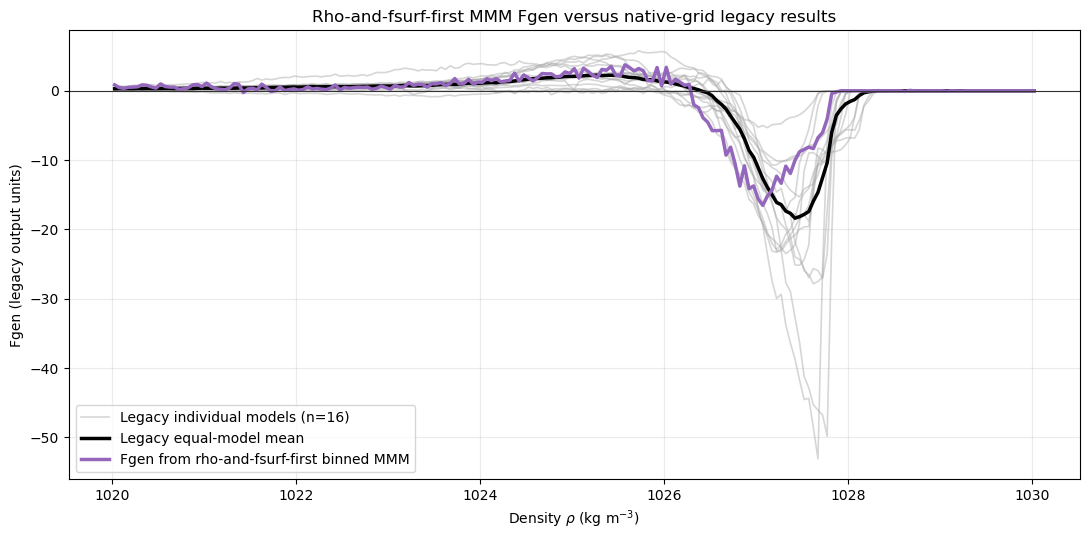

In [9]:
plot_mask = mmm_rho >= RHO_PLOT_MIN

fig, axis = plt.subplots(figsize=(11, 5.5))
for index, (model, profile) in enumerate(legacy_profiles.items()):
    axis.plot(
        profile.loc[plot_mask, "rho"],
        profile.loc[plot_mask, "Fgen"],
        color="0.65",
        alpha=0.45,
        linewidth=1.2,
        label=f"Legacy individual models (n={len(models_processed)})" if index == 0 else None,
    )
axis.plot(
    legacy_mean.loc[plot_mask, "rho"],
    legacy_mean.loc[plot_mask, "Fgen"],
    color="black",
    linewidth=2.5,
    label="Legacy equal-model mean",
)
axis.plot(
    mmm_profile.loc[plot_mask, "rho"],
    mmm_profile.loc[plot_mask, "Fgen"],
    color="tab:purple",
    linewidth=2.5,
    label="Fgen from rho-and-fsurf-first binned MMM",
)
axis.axhline(0.0, color="0.2", linewidth=0.8)
axis.set(
    xlabel=r"Density $\rho$ (kg m$^{-3}$)",
    ylabel="Fgen (legacy output units)",
    title="Rho-and-fsurf-first MMM Fgen versus native-grid legacy results",
)
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()


## Heat and freshwater components

Compare the terms separately before attributing an Fgen difference to either forcing component.


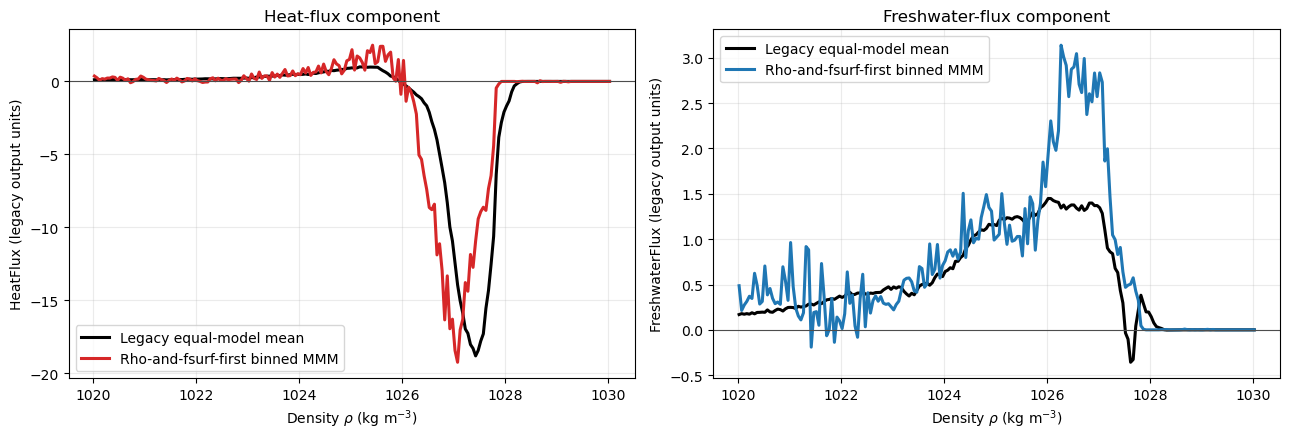

In [10]:
component_styles = {
    "HeatFlux": {"color": "tab:red", "title": "Heat-flux component"},
    "FreshwaterFlux": {"color": "tab:blue", "title": "Freshwater-flux component"},
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for axis, (column, style) in zip(axes, component_styles.items()):
    axis.plot(
        legacy_mean.loc[plot_mask, "rho"],
        legacy_mean.loc[plot_mask, column],
        color="black",
        linewidth=2.2,
        label="Legacy equal-model mean",
    )
    axis.plot(
        mmm_profile.loc[plot_mask, "rho"],
        mmm_profile.loc[plot_mask, column],
        color=style["color"],
        linewidth=2.2,
        label="Rho-and-fsurf-first binned MMM",
    )
    axis.axhline(0.0, color="0.3", linewidth=0.8)
    axis.set_title(style["title"])
    axis.set_xlabel(r"Density $\rho$ (kg m$^{-3}$)")
    axis.set_ylabel(f"{column} (legacy output units)")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()


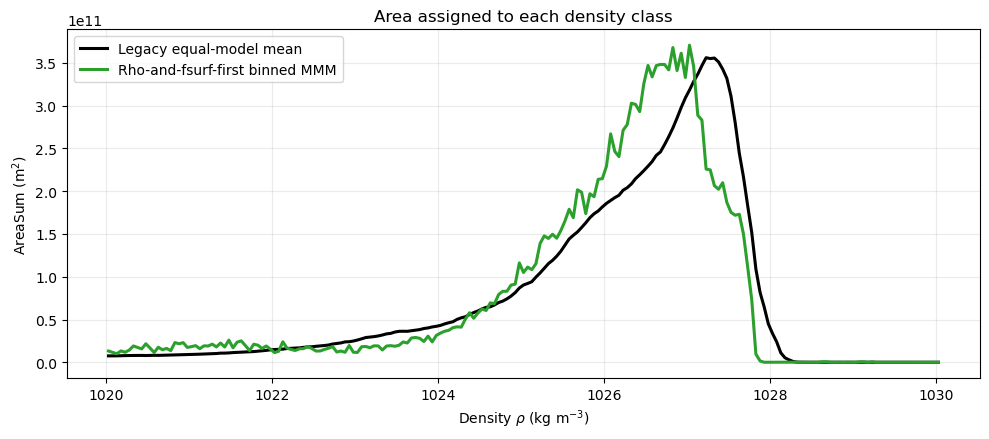

In [11]:
fig, axis = plt.subplots(figsize=(10, 4.5))
axis.plot(
    legacy_mean.loc[plot_mask, "rho"],
    legacy_mean.loc[plot_mask, "AreaSum"],
    color="black",
    linewidth=2.2,
    label="Legacy equal-model mean",
)
axis.plot(
    mmm_profile.loc[plot_mask, "rho"],
    mmm_profile.loc[plot_mask, "AreaSum"],
    color="tab:green",
    linewidth=2.2,
    label="Rho-and-fsurf-first binned MMM",
)
axis.set(
    xlabel=r"Density $\rho$ (kg m$^{-3}$)",
    ylabel=r"AreaSum (m$^2$)",
    title="Area assigned to each density class",
)
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()


## Rho-and-fsurf-first MMM minus legacy mean

Positive values indicate that the diagnostic computed with the rho-and-fsurf-first binned MMM is larger in that density class.


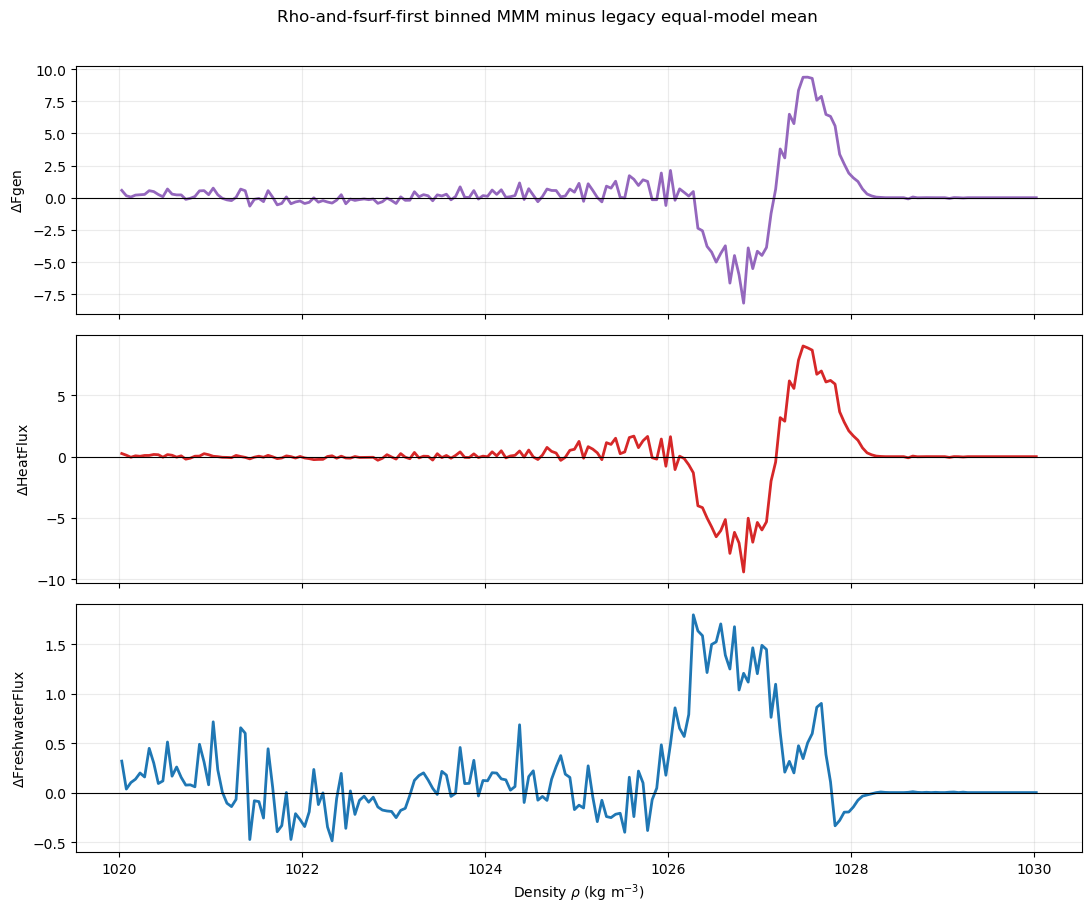

In [12]:
difference_profile = mmm_profile.copy()
difference_profile[PROFILE_COLUMNS] = (
    mmm_profile[PROFILE_COLUMNS].to_numpy() - legacy_mean[PROFILE_COLUMNS].to_numpy()
)

difference_columns = ["Fgen", "HeatFlux", "FreshwaterFlux"]
difference_colors = ["tab:purple", "tab:red", "tab:blue"]
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for axis, column, color in zip(axes, difference_columns, difference_colors):
    axis.plot(
        difference_profile.loc[plot_mask, "rho"],
        difference_profile.loc[plot_mask, column],
        color=color,
        linewidth=2.0,
    )
    axis.axhline(0.0, color="black", linewidth=0.8)
    axis.set_ylabel(f"$\Delta${column}")
    axis.grid(alpha=0.25)
axes[-1].set_xlabel(r"Density $\rho$ (kg m$^{-3}$)")
fig.suptitle("Rho-and-fsurf-first binned MMM minus legacy equal-model mean", y=1.01)
plt.tight_layout()
plt.show()


## Comparison metrics

Metrics use the plotted density range (`rho >= RHO_PLOT_MIN`). The negative integral is reported as a positive magnitude, integrating only the portion of Fgen below zero over density.


In [13]:
def negative_fgen_integral_magnitude(profile: pd.DataFrame) -> float:
    rho = profile["rho"].to_numpy(dtype=float)
    negative_magnitude = np.clip(-profile["Fgen"].to_numpy(dtype=float), 0.0, None)
    return float(np.trapz(negative_magnitude, rho))

def fgen_metrics(
    profile: pd.DataFrame,
    reference: pd.DataFrame,
) -> dict[str, float]:
    profile_eval = profile.loc[profile["rho"] >= RHO_PLOT_MIN].reset_index(drop=True)
    reference_eval = reference.loc[reference["rho"] >= RHO_PLOT_MIN].reset_index(drop=True)
    if not np.array_equal(profile_eval["rho"].to_numpy(), reference_eval["rho"].to_numpy()):
        raise AssertionError("Metric profiles do not have identical density coordinates")
    minimum_index = int(profile_eval["Fgen"].to_numpy().argmin())
    difference = profile_eval["Fgen"].to_numpy() - reference_eval["Fgen"].to_numpy()
    return {
        "Fgen_min": float(profile_eval.loc[minimum_index, "Fgen"]),
        "rho_at_Fgen_min_kg_m-3": float(profile_eval.loc[minimum_index, "rho"]),
        "RMSE_vs_legacy_mean": float(np.sqrt(np.mean(difference**2))),
        "max_abs_difference_vs_legacy_mean": float(np.max(np.abs(difference))),
        "negative_Fgen_integral_magnitude": negative_fgen_integral_magnitude(profile_eval),
    }

metric_table = pd.DataFrame(
    {
        "Legacy equal-model mean": fgen_metrics(legacy_mean, legacy_mean),
        "Fgen from rho-and-fsurf-first binned MMM": fgen_metrics(mmm_profile, legacy_mean),
    }
).T
metric_table.index.name = "profile"
metric_table


,Fgen_min,rho_at_Fgen_min_kg_m-3,RMSE_vs_legacy_mean,max_abs_difference_vs_legacy_mean,negative_Fgen_integral_magnitude
profile,,,,,
Legacy equal-model mean,-18.383801,1027.425,0.000000,0.00000,15.483090
Fgen from rho-and-fsurf-first binned MMM,-16.526160,1027.075,2.336869,9.37221,14.120983


## Interpretation checklist

- Treat the legacy equal-model mean as the reference, not any individual model.
- Use the component differences to identify whether heat or freshwater forcing dominates the Fgen change.
- Check the monthly `model_count` table before interpreting cells where the raw-variable MMM uses fewer than all 16 contributors.
- Use the effective-area diagnostics when interpreting `AreaSum`; the common-grid area is a mean of binned native-ocean areas.
- Differences include raw-first spatial averaging, temporal-climatology nonlinearity, and rho-and-fsurf-first model averaging: the MMM path diagnoses 12 monthly climatologies, while the legacy path averages diagnostics from 240 raw months.
- Saved mean-model rho controls density-class assignment, while saved mean-model fsurf, heat, and freshwater fields control the integrated forcing profiles. Diagnostics calculated from averaged raw inputs are used only for operation-order QC.
- The effective area remains the equal-cohort mean of binned native areas, so this experiment integrates `mean_model(fsurf) * mean_model(area)` rather than `mean_model(fsurf * area)`.
